# Agreement Experiments

This notebook tracks the current agreement experiment as compact batch outputs arrive. It joins model outputs back to local samples and grammars, scores exact match against both the canonical target and the full set of licensed targets, and summarizes results by agreement condition, intended grammar size, and sentence depth.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import json
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import pyrootutils

from IPython.display import display

PROJECT_ROOT = pyrootutils.find_root(indicator=".project-root")
DATA_DIR = PROJECT_ROOT / "data"
BATCHES_DIR = PROJECT_ROOT / "batches"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
FIGURES_DIR = NOTEBOOKS_DIR / "figures"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
EXP_NAME = "agreement"
EXP_DATA_DIR = DATA_DIR / f"{EXP_NAME}_exp"
EXP_BATCH_DIR = BATCHES_DIR / f"{EXP_NAME}_exp_compact"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GRAMMAR_LIST = EXP_DATA_DIR / f"{EXP_NAME}_grammars.txt"
assert GRAMMAR_LIST.exists(), GRAMMAR_LIST
assert EXP_DATA_DIR.exists(), EXP_DATA_DIR
assert EXP_BATCH_DIR.exists(), EXP_BATCH_DIR


## Define aesthetics

In [2]:
import aesthetics as aes  # noqa: F401

sns = aes.sns
plt = aes.plt
mtick = aes.mtick

aes.PALETTE_METRICS

AGREEMENT_CONDITION_ORDER = [
    "NoAgr → NoAgr",
    "Agr → NoAgr",
    "Agr → Agr",
    "NoAgr → Agr",
]

PALETTE_AGREEMENT = aes.darken(
    {
        "NoAgr → NoAgr": sns.color_palette("Dark2", n_colors=4)[0],
        "Agr → NoAgr": sns.color_palette("Dark2", n_colors=4)[1],
        "Agr → Agr": sns.color_palette("Dark2", n_colors=4)[2],
        "NoAgr → Agr": sns.color_palette("Dark2", n_colors=4)[3],
    },
    by=0.25,
)

# Set to a concrete model name to force plotting that model.
# Leave as None to auto-select from available rows.
PLOT_MODEL = None


## Load grammars and samples

In [3]:
with open(GRAMMAR_LIST) as f:
    grammar_ids = [line.strip() for line in f if line.strip()]


def load_grammar(grammar_id: str) -> dict:
    with open(EXP_DATA_DIR / f"grammar_{grammar_id}.json") as f:
        grammar = json.load(f)
    meta = grammar.get("agreement_metadata", {})
    a_enabled = bool(meta.get("a", {}).get("config", {}).get("enabled", False))
    b_enabled = bool(meta.get("b", {}).get("config", {}).get("enabled", False))
    grammar_size = 5 * len(grammar["a"]["verbs"])
    return {
        "grammar_name": grammar_id,
        "grammar_size": grammar_size,
        "n_words": grammar.get("n_words"),
        "n_rules": grammar.get("n_rules"),
        "agreement_enabled_a": a_enabled,
        "agreement_enabled_b": b_enabled,
        "agreement_condition": f"{'Agr' if a_enabled else 'NoAgr'} → {'Agr' if b_enabled else 'NoAgr'}",
    }


def extract_json_field(line: str, start_marker: str, end_markers: list[str]):
    start = line.index(start_marker) + len(start_marker)
    end = min(
        line.index(marker, start) for marker in end_markers if marker in line[start:]
    )
    return json.loads(line[start:end])


def load_sample_manifest(grammar_id: str) -> pd.DataFrame:
    rows = []
    with open(EXP_DATA_DIR / f"samples_{grammar_id}.jsonl") as f:
        for sample_id, line in enumerate(f):
            has_features = '"subject_features":' in line
            rows.append(
                {
                    "grammar_name": grammar_id,
                    "sample_id": str(sample_id),
                    "left_phonetic": extract_json_field(
                        line, '"left_phonetic": ', [', "right":']
                    ),
                    "right_phonetic": extract_json_field(
                        line,
                        '"right_phonetic": ',
                        [', "possible_right":', ', "left_tree":'],
                    ),
                    "depth": extract_json_field(
                        line,
                        '"depth": ',
                        [', "subject_features":', ', "grammar_name":'],
                    ),
                    "subject_features": extract_json_field(
                        line,
                        '"subject_features": ',
                        [', "verb_features":'],
                    )
                    if has_features
                    else {},
                    "verb_features": extract_json_field(
                        line,
                        '"verb_features": ',
                        [', "possible_right":'],
                    )
                    if has_features
                    else {},
                }
            )
    return pd.DataFrame(rows)


grammars_df = pd.DataFrame([load_grammar(grammar_id) for grammar_id in grammar_ids])
samples_df = pd.concat(
    [load_sample_manifest(grammar_id) for grammar_id in grammar_ids], ignore_index=True
)
grammars_df["agreement_condition"] = pd.Categorical(
    grammars_df["agreement_condition"],
    categories=AGREEMENT_CONDITION_ORDER,
    ordered=True,
)
samples_df["input_length"] = samples_df["left_phonetic"].str.split().str.len()
samples_df["target_length"] = samples_df["right_phonetic"].str.split().str.len()
samples_df["input_length_quintile"] = pd.qcut(
    samples_df["input_length"],
    q=5,
    duplicates="drop",
)
samples_df["input_length_quintile_mid"] = samples_df["input_length_quintile"].apply(
    lambda x: (x.left + x.right) / 2 if pd.notna(x) else np.nan
)
samples_df["subject_person"] = samples_df["subject_features"].apply(
    lambda x: x.get("person") if isinstance(x, dict) else None
)
samples_df["subject_number"] = samples_df["subject_features"].apply(
    lambda x: x.get("number") if isinstance(x, dict) else None
)
samples_df = samples_df.merge(grammars_df, on="grammar_name", how="left")
samples_df["agreement_condition"] = pd.Categorical(
    samples_df["agreement_condition"],
    categories=AGREEMENT_CONDITION_ORDER,
    ordered=True,
)

print(f"Grammars: {len(grammars_df)}")
print(f"Samples: {len(samples_df)}")
display(
    grammars_df.groupby(["agreement_condition", "grammar_size"], observed=False)
    .size()
    .rename("n_grammars")
    .reset_index()
)
display(
    samples_df.groupby(["agreement_condition", "input_length_quintile"], observed=False)
    .size()
    .rename("n_samples")
    .reset_index()
)


Grammars: 56
Samples: 6720


,agreement_condition,grammar_size,n_grammars
0,NoAgr → NoAgr,25,2
1,NoAgr → NoAgr,50,2
2,NoAgr → NoAgr,100,2
3,NoAgr → NoAgr,1000,2
4,NoAgr → NoAgr,5000,2
5,NoAgr → NoAgr,7500,2
6,NoAgr → NoAgr,10000,2
7,Agr → NoAgr,25,2
8,Agr → NoAgr,50,2
9,Agr → NoAgr,100,2


,agreement_condition,input_length_quintile,n_samples
0,NoAgr → NoAgr,"(2.999, 8.0]",367
1,NoAgr → NoAgr,"(8.0, 13.0]",339
2,NoAgr → NoAgr,"(13.0, 17.0]",285
3,NoAgr → NoAgr,"(17.0, 22.0]",377
4,NoAgr → NoAgr,"(22.0, 44.0]",312
5,Agr → NoAgr,"(2.999, 8.0]",398
6,Agr → NoAgr,"(8.0, 13.0]",330
7,Agr → NoAgr,"(13.0, 17.0]",306
8,Agr → NoAgr,"(17.0, 22.0]",352
9,Agr → NoAgr,"(22.0, 44.0]",294


In [4]:
samples_df.groupby("agreement_condition").agg(
    samples=("sample_id", "size"),
    mean_input_length=("input_length", "mean"),
    mean_target_length=("target_length", "mean"),
).round(2).reset_index()


/var/folders/70/m9xv6w4j3bl15rm0jsz76ltm0000gn/T/ipykernel_87340/2124117480.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_df.groupby("agreement_condition").agg(


,agreement_condition,samples,mean_input_length,mean_target_length
0,NoAgr → NoAgr,1680,15.52,16.35
1,Agr → NoAgr,1680,15.01,14.66
2,Agr → Agr,1680,15.40,15.00
3,NoAgr → Agr,1680,15.08,15.02


## Load available batch outputs

In [5]:
CUSTOM_ID_RE = re.compile(
    r"^(?P<grammar_name>[0-9a-f]+)-(?P<input_hash>[0-9a-f]+)-sample-(?P<sample_id>\d+)$"
)
ANSWER_RE = re.compile(
    r"final\s*answer\s*(?::|-|—)?\s*(?:is\s*)?([^\n]+)", re.IGNORECASE | re.DOTALL
)


def fuzzy_model(model: str) -> str:
    return re.sub(r"-\d{4}-\d{2}-\d{2}$", "", model or "")


def extract_answer(model_response: str | None) -> str | None:
    if not model_response:
        return None
    matches = ANSWER_RE.findall(model_response)
    if not matches:
        return None
    answer = matches[-1].strip()
    answer = re.sub(r"[^\w\s]", "", answer, flags=re.UNICODE).strip()
    return answer or None


def parse_usage(body: dict) -> tuple[int | None, int | None, int | None]:
    usage = body.get("usage", {}) or {}
    if "prompt_tokens" in usage:
        return (
            usage.get("prompt_tokens"),
            usage.get("completion_tokens"),
            usage.get("total_tokens"),
        )
    return (
        usage.get("promptTokens"),
        usage.get("completionTokens"),
        usage.get("totalTokens"),
    )


def load_outputs(batch_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(batch_dir.glob("*_output.jsonl")):
        with open(path) as f:
            for line in f:
                item = json.loads(line)
                body = (item.get("response") or {}).get("body") or {}
                message = None
                choices = body.get("choices") or []
                if choices:
                    message = ((choices[0] or {}).get("message") or {}).get("content")
                prompt_tokens, completion_tokens, total_tokens = parse_usage(body)
                match = CUSTOM_ID_RE.match(item.get("custom_id", ""))
                if not match:
                    continue
                row = {
                    "batch_file": path.name,
                    "batch_id": path.name.replace("_output.jsonl", ""),
                    "custom_id": item.get("custom_id"),
                    "grammar_name": match.group("grammar_name"),
                    "input_hash": match.group("input_hash"),
                    "sample_id": match.group("sample_id"),
                    "model": body.get("model"),
                    "fuzzy_model": fuzzy_model(body.get("model", "")),
                    "model_response": message,
                    "model_answer": extract_answer(message),
                    "status_code": (item.get("response") or {}).get("status_code"),
                    "error": item.get("error"),
                    "prompt_tokens": prompt_tokens,
                    "completion_tokens": completion_tokens,
                    "total_tokens": total_tokens,
                }
                rows.append(row)
    return pd.DataFrame(rows)


outputs_df = load_outputs(EXP_BATCH_DIR)
print(f"Output rows loaded: {len(outputs_df)}")
if len(outputs_df):
    display(
        outputs_df.groupby(["batch_file", "fuzzy_model"])
        .size()
        .rename("n_rows")
        .reset_index()
    )
else:
    print("No batch output files found yet.")


Output rows loaded: 20160


,batch_file,fuzzy_model,n_rows
0,batch_69b45c5084708190b3acd95cf1a78760_output....,gpt-5-nano,6720
1,batch_69b45c85376481909ec2bd144f3bd831_output....,gpt-5-mini,6720
2,batch_69b45ca7adcc81908ba999a73c019d95_output....,gpt-5,6720


## Merge outputs with samples

In [6]:
def json_string_array_contains(array_text: str, value: str | None) -> bool:
    if not value:
        return False
    needle = json.dumps(value, ensure_ascii=False)
    return any(
        token in array_text
        for token in (
            f"[{needle}]",
            f"[{needle}, ",
            f", {needle}, ",
            f", {needle}]",
        )
    )


def count_json_string_array_items(array_text: str) -> int:
    array_text = array_text.strip()
    if array_text == "[]":
        return 0
    return array_text.count('", "') + 1


def extract_possible_right_phonetic_array(line: str) -> str:
    start_marker = '"possible_right_phonetic": '
    end_markers = [', "agreement_ok":', ', "left_tree":', ', "grammar_name":']
    start = line.index(start_marker) + len(start_marker)
    end = min(
        line.index(marker, start) for marker in end_markers if marker in line[start:]
    )
    return line[start:end]


def load_reference_stats_for_outputs(outputs_df: pd.DataFrame) -> pd.DataFrame:
    if outputs_df.empty:
        return pd.DataFrame(
            columns=[
                "grammar_name",
                "sample_id",
                "reference_count",
                "is_ambiguous",
                "exact_match_any",
            ]
        )

    outputs_df = outputs_df.copy()
    outputs_df["reference_count"] = np.nan
    outputs_df["is_ambiguous"] = False
    outputs_df["exact_match_any"] = False

    needed = {}
    for idx, row in outputs_df.iterrows():
        needed.setdefault(row["grammar_name"], {}).setdefault(
            row["sample_id"], []
        ).append(idx)

    for grammar_name, sample_map in needed.items():
        sample_path = EXP_DATA_DIR / f"samples_{grammar_name}.jsonl"
        with open(sample_path) as f:
            for sample_idx, line in enumerate(f):
                sample_id = str(sample_idx)
                if sample_id not in sample_map:
                    continue
                array_text = extract_possible_right_phonetic_array(line)
                ref_count = count_json_string_array_items(array_text)
                for row_idx in sample_map[sample_id]:
                    answer = outputs_df.at[row_idx, "model_answer"]
                    outputs_df.at[row_idx, "reference_count"] = ref_count
                    outputs_df.at[row_idx, "is_ambiguous"] = ref_count > 1
                    outputs_df.at[row_idx, "exact_match_any"] = (
                        json_string_array_contains(array_text, answer)
                    )

    return outputs_df


merged_df = (
    outputs_df.merge(
        samples_df,
        on=["grammar_name", "sample_id"],
        how="left",
        validate="many_to_one",
    )
    if len(outputs_df)
    else pd.DataFrame()
)

if len(merged_df):
    merged_df = merged_df.drop_duplicates(subset=["batch_id", "custom_id"]).copy()
    merged_df = load_reference_stats_for_outputs(merged_df)
    merged_df["has_answer"] = merged_df["model_answer"].notna()
    merged_df["exact_match_canonical"] = merged_df.apply(
        lambda row: row["model_answer"] == row["right_phonetic"]
        if row["model_answer"]
        else False,
        axis=1,
    )
    merged_df["length_delta"] = merged_df.apply(
        lambda row: len(row["model_answer"].split()) - row["target_length"]
        if row["model_answer"]
        else np.nan,
        axis=1,
    )
    merged_df["ambiguity_bonus"] = (
        merged_df["exact_match_any"] & ~merged_df["exact_match_canonical"]
    )
    completion_rate = len(merged_df) / len(samples_df)
    print(
        f"Completed rows: {len(merged_df)} / {len(samples_df)} ({completion_rate:.1%})"
    )
    display(merged_df.head())
else:
    print("No outputs merged yet.")


Completed rows: 20160 / 6720 (300.0%)


,batch_file,batch_id,custom_id,grammar_name,input_hash,sample_id,model,fuzzy_model,model_response,model_answer,...,agreement_enabled_a,agreement_enabled_b,agreement_condition,reference_count,is_ambiguous,exact_match_any,has_answer,exact_match_canonical,length_delta,ambiguity_bonus
0,batch_69b45c5084708190b3acd95cf1a78760_output....,batch_69b45c5084708190b3acd95cf1a78760,179d4d1c734893f7-c4a6f3-sample-0,179d4d1c734893f7,c4a6f3,0,gpt-5-nano-2025-08-07,gpt-5-nano,Final answer: bayqat quprolhas faqgac bayqat k...,bayqat quprolhas faqgac bayqat karbagtac,...,False,False,NoAgr → NoAgr,1.0,False,True,True,True,0,False
1,batch_69b45c5084708190b3acd95cf1a78760_output....,batch_69b45c5084708190b3acd95cf1a78760,179d4d1c734893f7-c4a6f3-sample-1,179d4d1c734893f7,c4a6f3,1,gpt-5-nano-2025-08-07,gpt-5-nano,Final answer: cactebxub pejxirpap zazyep qupro...,cactebxub pejxirpap zazyep quprolhas,...,False,False,NoAgr → NoAgr,1.0,False,True,True,True,0,False
2,batch_69b45c5084708190b3acd95cf1a78760_output....,batch_69b45c5084708190b3acd95cf1a78760,179d4d1c734893f7-c4a6f3-sample-2,179d4d1c734893f7,c4a6f3,2,gpt-5-nano-2025-08-07,gpt-5-nano,Final answer: zazyep havlamqidhaz vetfuphup pe...,zazyep havlamqidhaz vetfuphup pejxirpap zazyep...,...,False,False,NoAgr → NoAgr,1.0,False,True,True,True,0,False
3,batch_69b45c5084708190b3acd95cf1a78760_output....,batch_69b45c5084708190b3acd95cf1a78760,179d4d1c734893f7-c4a6f3-sample-3,179d4d1c734893f7,c4a6f3,3,gpt-5-nano-2025-08-07,gpt-5-nano,Final answer: karbagtac nusyojtaz bayqat qupro...,karbagtac nusyojtaz bayqat quprolhas,...,False,False,NoAgr → NoAgr,1.0,False,True,True,True,0,False
4,batch_69b45c5084708190b3acd95cf1a78760_output....,batch_69b45c5084708190b3acd95cf1a78760,179d4d1c734893f7-c4a6f3-sample-4,179d4d1c734893f7,c4a6f3,4,gpt-5-nano-2025-08-07,gpt-5-nano,Final answer: nimgoh nusyojtaz bayqat bof,nimgoh nusyojtaz bayqat bof,...,False,False,NoAgr → NoAgr,1.0,False,True,True,True,0,False


## Progress snapshot

In [7]:
if len(merged_df):
    progress_by_cell = (
        merged_df.groupby(["agreement_condition", "grammar_size", "depth"])
        .size()
        .rename("completed")
        .reset_index()
    )
    target_by_cell = (
        samples_df.groupby(["agreement_condition", "grammar_size", "depth"])
        .size()
        .rename("expected")
        .reset_index()
    )
    progress_df = target_by_cell.merge(
        progress_by_cell,
        on=["agreement_condition", "grammar_size", "depth"],
        how="left",
    ).fillna({"completed": 0})
    progress_df["completed"] = progress_df["completed"].astype(int)
    progress_df["pct_complete"] = progress_df["completed"] / progress_df["expected"]
    display(
        progress_df.sort_values(["agreement_condition", "grammar_size", "depth"]).head(
            20
        )
    )
else:
    progress_df = pd.DataFrame()
    print("No progress to report yet.")


/var/folders/70/m9xv6w4j3bl15rm0jsz76ltm0000gn/T/ipykernel_87340/3238420069.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby(["agreement_condition", "grammar_size", "depth"])
/var/folders/70/m9xv6w4j3bl15rm0jsz76ltm0000gn/T/ipykernel_87340/3238420069.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  samples_df.groupby(["agreement_condition", "grammar_size", "depth"])


,agreement_condition,grammar_size,depth,expected,completed,pct_complete
0,NoAgr → NoAgr,25,0,40,120,3.0
1,NoAgr → NoAgr,25,1,40,120,3.0
2,NoAgr → NoAgr,25,2,40,120,3.0
3,NoAgr → NoAgr,25,3,40,120,3.0
4,NoAgr → NoAgr,25,4,40,120,3.0
5,NoAgr → NoAgr,25,5,40,120,3.0
6,NoAgr → NoAgr,50,0,40,120,3.0
7,NoAgr → NoAgr,50,1,40,120,3.0
8,NoAgr → NoAgr,50,2,40,120,3.0
9,NoAgr → NoAgr,50,3,40,120,3.0


## Accuracy metrics

In [8]:
if len(merged_df):
    from difflib import SequenceMatcher

    try:
        import evaluate
    except ImportError:
        evaluate = None

    try:
        import sacrebleu
    except ImportError:
        sacrebleu = None

    def bow_match(row) -> bool:
        if row["model_answer"] is None or row["right_phonetic"] is None:
            return False
        return sorted(row["model_answer"].split()) == sorted(
            row["right_phonetic"].split()
        )

    def edit_similarity(row) -> float:
        pred = row["model_answer"] or ""
        ref = row["right_phonetic"] or ""
        return SequenceMatcher(None, pred, ref).ratio()

    def bleu_score(row) -> float:
        if sacrebleu is None:
            return np.nan
        pred = row["model_answer"] or ""
        ref = row["right_phonetic"] or ""
        return sacrebleu.sentence_bleu(pred, [ref]).score / 100.0

    merged_df["bow_match"] = merged_df.apply(bow_match, axis=1)
    merged_df["edit_similarity"] = merged_df.apply(edit_similarity, axis=1)
    merged_df["bleu"] = merged_df.apply(bleu_score, axis=1)

    if evaluate is not None:
        chrf = evaluate.load("chrf")
        merged_df["chrF++"] = [
            chrf.compute(
                predictions=[pred or ""],
                references=[[ref or ""]],
                beta=2,
                word_order=2,
            )["score"]
            / 100.0
            for pred, ref in zip(merged_df["model_answer"], merged_df["right_phonetic"])
        ]
    else:
        merged_df["chrF++"] = np.nan

    summary_by_model = (
        merged_df.groupby(["fuzzy_model"])
        .agg(
            rows=("custom_id", "size"),
            answered=("has_answer", "sum"),
            exact_match_canonical=("exact_match_canonical", "mean"),
            exact_match_any=("exact_match_any", "mean"),
            bow_match=("bow_match", "mean"),
            edit_similarity=("edit_similarity", "mean"),
            bleu=("bleu", "mean"),
            chrf_pp=("chrF++", "mean"),
            ambiguity_bonus=("ambiguity_bonus", "mean"),
            mean_prompt_tokens=("prompt_tokens", "mean"),
            mean_completion_tokens=("completion_tokens", "mean"),
        )
        .reset_index()
    )
    for col in [
        "exact_match_canonical",
        "exact_match_any",
        "bow_match",
        "edit_similarity",
        "bleu",
        "chrf_pp",
        "ambiguity_bonus",
    ]:
        summary_by_model[col] = (100 * summary_by_model[col]).round(2)
    summary_by_model
else:
    print("No outputs available for scoring yet.")


In [13]:
PLOT_MODEL = "gpt-5"
# PLOT_MODEL = None

In [14]:
if len(merged_df):
    merged_df["agreement_condition"] = pd.Categorical(
        merged_df["agreement_condition"],
        categories=AGREEMENT_CONDITION_ORDER,
        ordered=True,
    )

    by_condition = (
        merged_df.groupby(["agreement_condition", "fuzzy_model"], observed=False)
        .agg(
            rows=("custom_id", "size"),
            exact_match_canonical=("exact_match_canonical", "mean"),
            exact_match_any=("exact_match_any", "mean"),
            bow_match=("bow_match", "mean"),
            edit_similarity=("edit_similarity", "mean"),
            bleu=("bleu", "mean"),
            chrf_pp=("chrF++", "mean"),
            ambiguity_rate=("is_ambiguous", "mean"),
            ambiguity_bonus=("ambiguity_bonus", "mean"),
        )
        .reset_index()
    )
    for col in [
        "exact_match_canonical",
        "exact_match_any",
        "bow_match",
        "edit_similarity",
        "bleu",
        "chrf_pp",
        "ambiguity_rate",
        "ambiguity_bonus",
    ]:
        by_condition[col] = (100 * by_condition[col]).round(2)
    display(by_condition.sort_values(["fuzzy_model", "agreement_condition"]))

    metrics_for_plot = [
        ("exact_match_any", "Exact Match"),
        ("bow_match", "Bag of Words"),
        ("bleu", "BLEU Score"),
        ("chrF++", "chrF++"),
    ]

    plot_model_candidates = sorted(merged_df["fuzzy_model"].dropna().unique())
    if PLOT_MODEL is None:
        selected_model = plot_model_candidates[-1] if plot_model_candidates else None
    else:
        selected_model = PLOT_MODEL
    print(f"Plotting model: {selected_model}")

    plot_source_df = merged_df[merged_df["fuzzy_model"] == selected_model].copy()
    plot_source_df["agreement_condition"] = pd.Categorical(
        plot_source_df["agreement_condition"],
        categories=AGREEMENT_CONDITION_ORDER,
        ordered=True,
    )

    plot_metric_df = plot_source_df.melt(
        id_vars=[
            "agreement_condition",
            "input_length_quintile_mid",
            "input_length_quintile",
            "grammar_size",
        ],
        value_vars=[col for col, _ in metrics_for_plot],
        var_name="metric_key",
        value_name="match_value",
    )
    plot_metric_df["match_type"] = plot_metric_df["metric_key"].replace(
        {col: name for col, name in metrics_for_plot}
    )
    plot_metric_df["match_value"] = plot_metric_df["match_value"].astype(float)

    plot_length_df = plot_metric_df.copy()
    plot_size_df = plot_metric_df.copy()
else:
    plot_length_df = pd.DataFrame()
    plot_size_df = pd.DataFrame()
    selected_model = None


,agreement_condition,fuzzy_model,rows,exact_match_canonical,exact_match_any,bow_match,edit_similarity,bleu,chrf_pp,ambiguity_rate,ambiguity_bonus
0,NoAgr → NoAgr,gpt-5,1680,89.76,89.76,89.76,99.31,98.07,98.93,0.0,0.00
3,Agr → NoAgr,gpt-5,1680,37.56,37.56,37.56,94.19,82.17,89.69,0.0,0.00
6,Agr → Agr,gpt-5,1680,38.39,38.39,38.45,94.25,82.89,90.90,0.0,0.00
9,NoAgr → Agr,gpt-5,1680,23.57,35.89,23.57,91.84,72.69,85.18,100.0,12.32
1,NoAgr → NoAgr,gpt-5-mini,1680,89.17,89.17,89.17,99.23,97.82,98.81,0.0,0.00
4,Agr → NoAgr,gpt-5-mini,1680,37.14,37.14,37.14,94.07,81.89,89.57,0.0,0.00
7,Agr → Agr,gpt-5-mini,1680,37.50,37.50,37.50,94.01,82.46,90.76,0.0,0.00
10,NoAgr → Agr,gpt-5-mini,1680,23.63,35.83,23.63,91.76,71.85,84.81,100.0,12.20
2,NoAgr → NoAgr,gpt-5-nano,1680,65.54,65.54,65.54,96.40,89.57,94.46,0.0,0.00
5,Agr → NoAgr,gpt-5-nano,1680,28.15,28.15,28.21,90.00,72.49,83.95,0.0,0.00


Plotting model: gpt-5


## Plots

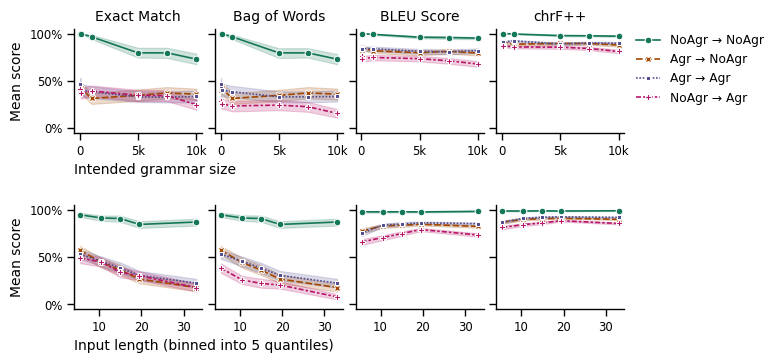

In [15]:
if len(plot_length_df):
    PERF_METRICS = ["Exact Match", "Bag of Words", "BLEU Score", "chrF++"]
    fig = plt.figure(figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_DOUBLEROW_DIFFAXES_IN))
    grid = fig.add_gridspec(2, len(PERF_METRICS), wspace=0.1, hspace=0.7)

    with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
        for r in range(2):
            for i, metric_name in enumerate(PERF_METRICS):
                ax = fig.add_subplot(grid[r, i])

                if r == 1:
                    sns.lineplot(
                        data=plot_length_df[
                            plot_length_df["match_type"] == metric_name
                        ],
                        x="input_length_quintile_mid",
                        y="match_value",
                        hue="agreement_condition",
                        style="agreement_condition",
                        hue_order=AGREEMENT_CONDITION_ORDER,
                        style_order=AGREEMENT_CONDITION_ORDER,
                        markers=True,
                        ax=ax,
                        palette=PALETTE_AGREEMENT,
                        legend=True,
                        errorbar="ci",
                    )
                    ax.set_xlabel(
                        "Input length (binned into 5 quantiles)",
                        loc="left" if i == 0 else "center",
                    )
                    # ax.set_xticks(sorted(plot_length_df["input_length_quintile_mid"].dropna().unique()))
                else:
                    sns.lineplot(
                        data=plot_size_df[plot_size_df["match_type"] == metric_name],
                        x="grammar_size",
                        y="match_value",
                        hue="agreement_condition",
                        style="agreement_condition",
                        hue_order=AGREEMENT_CONDITION_ORDER,
                        style_order=AGREEMENT_CONDITION_ORDER,
                        markers=True,
                        ax=ax,
                        palette=PALETTE_AGREEMENT,
                        legend=True,
                        errorbar="ci",
                    )
                    ax.set_xlabel(
                        "Intended grammar size",
                        loc="left" if i == 0 else "center",
                    )
                    # ax.set_xscale("log")
                    # ax.set_xticks(sorted(plot_size_df["grammar_size"].dropna().unique()))
                    ax.xaxis.set_major_formatter(aes.KMB_FORMATTER)

                ax.set_ylim(-0.05, 1.05)
                ax.yaxis.set_major_formatter(aes.PCT_FORMATTER)
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)
                if r == 0:
                    ax.set_title(metric_name)

                if i == 0:
                    ax.set_ylabel("Mean score")
                else:
                    ax.set_ylabel("")
                    ax.yaxis.set_ticklabels([])
                    ax.set_xlabel("")

                if (i == len(PERF_METRICS) - 1) and (r == 0):
                    ax.legend(
                        title="",
                        bbox_to_anchor=(1.05, 1.0),
                        loc="upper left",
                        borderaxespad=0,
                        frameon=False,
                    )
                else:
                    legend = ax.get_legend()
                    if legend is not None:
                        legend.remove()

    plt.subplots_adjust(left=0, bottom=0, right=1, top=1)
    plt.savefig(FIGURES_DIR / f"{selected_model}_agreement.pdf", bbox_inches="tight")
    plt.savefig(
        FIGURES_DIR / f"{selected_model}_agreement.png", bbox_inches="tight", dpi=300
    )

    plt.show()
else:
    print("No scored outputs available yet for plotting.")


## Ambiguous examples

In [12]:
if len(merged_df):
    ambiguous_hits = merged_df[merged_df["ambiguity_bonus"]].copy()
    cols = [
        "grammar_name",
        "sample_id",
        "agreement_condition",
        "depth",
        "left_phonetic",
        "model_answer",
        "right_phonetic",
        "reference_count",
    ]
    display(ambiguous_hits[cols].head(20))
else:
    print("No ambiguous matches to inspect yet.")


,grammar_name,sample_id,agreement_condition,depth,left_phonetic,model_answer,right_phonetic,reference_count
1681,1a27cdd22b89226b,1,NoAgr → Agr,0,numjaz yok baysaywezruy vowdew giy,fejzuldax huctiryeqjol hudnavfidzib fedgaddij ...,fejzuldax huctiryeqjol hudnavfidzib fedgaddij ...,12.0
1692,1a27cdd22b89226b,12,NoAgr → Agr,0,numjaz biglihlec baysaywezruy xoy yen foqmew giy,fejzuldax kixzewnoz kuthoj hudnavfidzib mahrog...,fejzuldax kixzewnoz kutjol hudnavfidzib mahrog...,12.0
1694,1a27cdd22b89226b,14,NoAgr → Agr,0,nikgebpix yok rawkartiy besmexxev,worxuf huctiryeqfiz hujvaz zic,worxuf huctiryeqfiz hujvaz zichuq,12.0
1710,1a27cdd22b89226b,30,NoAgr → Agr,1,zamraf yok qapgiq yowqeg tes puw purtef baysay...,xoqmiz huctiryeqqoh ceb riv rohsaf wesqoh hudn...,xoqmiz huctiryeqqoh ceb riv rohsaf wesjol hudn...,72.0
1713,1a27cdd22b89226b,33,NoAgr → Agr,1,qellay yok qapgiq yowqeg tes puw yiv yowqeg te...,nufxoqnakguy huctiryeqhoj ceb riv jikpoqfanhoj...,nufxoqnakguy huctiryeqhoj ceb riv jikpoqfanjol...,36.0
1715,1a27cdd22b89226b,35,NoAgr → Agr,1,rawkartiy giy xof luf rawkartiy vowdew giy big...,hujvaz fitwad lar dezpacjol nol hujvaz fedgadd...,hujvaz fitwadhuq lar dezpachoj nol hujvaz fedg...,144.0
1721,1a27cdd22b89226b,41,NoAgr → Agr,2,zamraf biglihlec qapgiq kapsefpobwec yok luf q...,xoqmiz kixzewnoz kutqoh ceb hucmolkug huctirye...,xoqmiz kixzewnoz kutqoh ceb hucmolkug huctirye...,216.0
1723,1a27cdd22b89226b,43,NoAgr → Agr,2,yowqeg tes puw yok qapgiq jem xof luf rawkarti...,riv huctiryeqjol ceb bacjej lar dezpacjol nol ...,riv huctiryeqjol ceb bacjej lar dezpacjol nol ...,432.0
1724,1a27cdd22b89226b,44,NoAgr → Agr,2,qellay biglihlec luf zamraf xof qapgiq nikgebp...,nufxoqnakguy kixzewnoz kuthoj nol xoqmiz lar d...,nufxoqnakguy kixzewnoz kuthoj nol xoqmiz lar d...,216.0
1727,1a27cdd22b89226b,47,NoAgr → Agr,2,yowqeg tes puw biglihlec qapgiq nikgebpix yok ...,riv kixzewnoz kutjol ceb worxuf huctiryeqfiz n...,riv kixzewnoz kutjol ceb worxuf huctiryeqfiz n...,216.0


## Notes

- Agreement conditions are ordered from easiest to hardest as: `NoAgr → NoAgr`, `Agr → NoAgr`, `Agr → Agr`, `NoAgr → Agr`.
- Rationale: dropping agreement on the target side is easier than producing it, and the hardest case is when the target requires agreement that the source does not overtly realize.
- `exact_match_any` is ambiguity-aware and uses the full `possible_right_phonetic` set.
- The heuristic metrics (`Bag of Words`, `Edit Similarity`, `BLEU`, `chrF++`) are currently computed against the single canonical target string.
- The notebook still avoids materializing the giant alternative lists during the initial sample load.
- Re-run the notebook as new `*_output.jsonl` files land in `batches/agreement_exp/`.
